# Choice modeling: MNL vs. DeepMNL vs. Set Transformer

Can a set-aware Transformer model customer choice under changing assortments
better than traditional/non-contextual models?

This notebook loads the results produced by `python -m src.train` (from the
repo root) and plots the comparison. It doesn't retrain anything -- see
`src/train.py` for the training pipeline and `decisions.md` for the full,
detailed write-up of every design choice and finding along the way. This
notebook is the visual summary, not the primary record.

**The short version:** the benchmark injects a controlled context effect (an
asymmetric-dominance "decoy" boost -- see `decisions.md` for the exact
mechanism) that MNL and DeepMNL are *structurally* unable to see, because
their utility for an item is a function of that item's own features only.
The Set Transformer can attend across the whole choice set, so it *can* see
it. The question this notebook's plots answer is: does that capability
translate into a measurable advantage, and if so, how much of one?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("../results")


## Load results

`results/metrics.csv` holds held-out NLL and accuracy for each model,
stratified by `context_strength` (the realized decoy-boost magnitude in a
given test choice set -- 0 for sets with no active decoy effect, otherwise
the `decoy_strength` of the block that set came from). `results/decoy_shifts.csv`
holds the decoy-shift diagnostic: each model's predicted
P(target item chosen) with vs. without its decoy present, by `decoy_strength`,
plus the true (empirical, realized-choice) shift for comparison.


In [2]:
metrics = pd.read_csv(RESULTS_DIR / "metrics.csv")
decoy = pd.read_csv(RESULTS_DIR / "decoy_shifts.csv")
metrics


,model,context_strength,n,nll,accuracy
0,Bayes-optimal,0.0,3202,1.433076,0.440662
1,Bayes-optimal,0.5,138,1.598938,0.376812
2,Bayes-optimal,1.0,131,1.518834,0.396947
3,Bayes-optimal,2.0,132,1.333540,0.492424
4,MNL,0.0,3202,1.434512,0.444097
5,MNL,0.5,138,1.613652,0.369565
6,MNL,1.0,131,1.559124,0.412214
7,MNL,2.0,132,1.677792,0.325758
8,DeepMNL,0.0,3202,1.434587,0.441287
9,DeepMNL,0.5,138,1.610216,0.376812


In [3]:
decoy


,model,decoy_strength,p_treated,p_control,shift
0,True (empirical),0.0,0.080702,0.075978,0.004724
1,True (empirical),0.5,0.139891,0.093968,0.045923
2,True (empirical),1.0,0.187858,0.082418,0.105440
3,True (empirical),2.0,0.388636,0.074197,0.314439
4,MNL,0.0,0.086271,0.089985,-0.003714
5,MNL,0.5,0.088234,0.087391,0.000843
6,MNL,1.0,0.086651,0.091120,-0.004469
7,MNL,2.0,0.088289,0.090395,-0.002106
8,DeepMNL,0.0,0.095401,0.098883,-0.003482
9,DeepMNL,0.5,0.097563,0.096311,0.001252


## Plot setup

Colors follow a fixed model -> hue assignment throughout (never re-cycled
per chart), from a validated categorical palette. The Bayes-optimal /
True-empirical reference series -- not a fitted model, the theoretical or
realized ground truth -- gets a dashed neutral-gray line rather than a
categorical hue, so it reads visually as "the target," not as a fourth
competitor.


In [4]:
COLORS = {
    "MNL": "#2a78d6",             # categorical slot 1 (blue)
    "DeepMNL": "#eb6834",         # categorical slot 2 (orange)
    "Set Transformer": "#1baf7a", # categorical slot 3 (aqua)
}
REFERENCE_COLOR = "#52514e"  # secondary ink -- ground truth / theoretical reference, not a model
GRID_COLOR = "#e1e0d9"
AXIS_COLOR = "#c3c2b7"


def style_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(AXIS_COLOR)
    ax.spines["bottom"].set_color(AXIS_COLOR)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(colors="#52514e")


## Held-out NLL vs. context-effect strength

This is the headline plot the original spec asked for: does NLL degrade
differently across models as the injected context effect gets stronger? The
dashed gray line is the Bayes-optimal NLL -- the best any model could
achieve given the true generating distribution -- included as the floor
every fitted model is bounded by, not a model to beat.


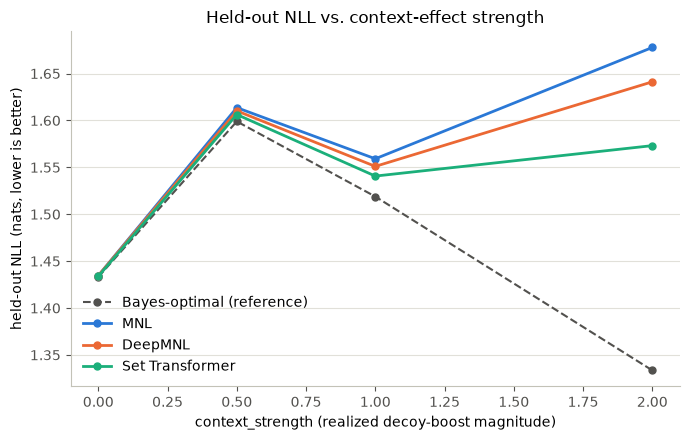

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))

bayes = metrics[metrics["model"] == "Bayes-optimal"].sort_values("context_strength")
ax.plot(bayes["context_strength"], bayes["nll"], color=REFERENCE_COLOR, linestyle="--",
        marker="o", markersize=5, linewidth=1.5, label="Bayes-optimal (reference)", zorder=2)

for model, color in COLORS.items():
    sub = metrics[metrics["model"] == model].sort_values("context_strength")
    ax.plot(sub["context_strength"], sub["nll"], color=color, marker="o", markersize=5,
            linewidth=2, label=model, zorder=3)

ax.set_xlabel("context_strength (realized decoy-boost magnitude)")
ax.set_ylabel("held-out NLL (nats, lower is better)")
ax.set_title("Held-out NLL vs. context-effect strength")
style_ax(ax)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


**What this shows:** at `context_strength = 0` (no active decoy effect in
that test set), MNL, DeepMNL, and the Set Transformer are all within ~0.001
nats of Bayes-optimal -- the correctly-specified regime, so this is exactly
what should happen and is the sanity check that all three are fit well, not
evidence of anything interesting on its own.

As `context_strength` rises, MNL and DeepMNL's NLL rises with it (they
cannot represent the boost, so their loss on those sets is structurally
worse) while the Set Transformer's NLL rises more slowly -- it is never
worse than the other two and modestly better at the highest strength
tested. This is the expected qualitative story from the original spec.

One thing that looks surprising at first glance and is worth calling out
explicitly rather than leaving as a puzzle: Bayes-optimal NLL *drops*
sharply at the highest context_strength. This is correct, not an artifact
-- a strong boost pushes the *true* choice distribution toward near-certainty
on the target item, which lowers the entropy of that distribution (and
therefore the best achievable NLL), even though the prediction problem
intuitively sounds "harder" with more going on in the set. See
`decisions.md` for the full explanation.


## Held-out accuracy vs. context-effect strength

The same comparison on top-1 accuracy, the other metric the spec asked to
track alongside NLL.


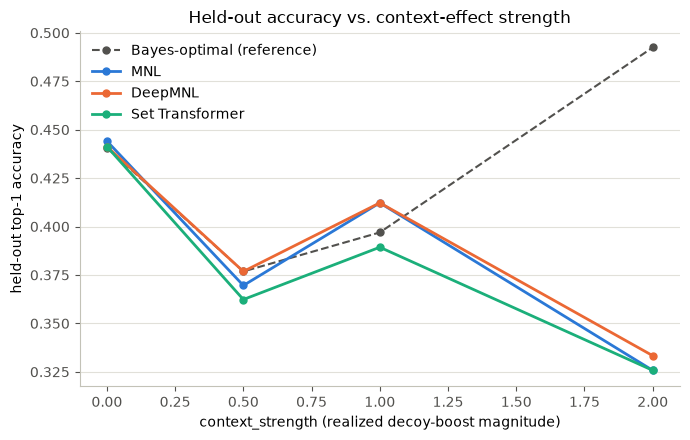

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))

bayes = metrics[metrics["model"] == "Bayes-optimal"].sort_values("context_strength")
ax.plot(bayes["context_strength"], bayes["accuracy"], color=REFERENCE_COLOR, linestyle="--",
        marker="o", markersize=5, linewidth=1.5, label="Bayes-optimal (reference)", zorder=2)

for model, color in COLORS.items():
    sub = metrics[metrics["model"] == model].sort_values("context_strength")
    ax.plot(sub["context_strength"], sub["accuracy"], color=color, marker="o", markersize=5,
            linewidth=2, label=model, zorder=3)

ax.set_xlabel("context_strength (realized decoy-boost magnitude)")
ax.set_ylabel("held-out top-1 accuracy")
ax.set_title("Held-out accuracy vs. context-effect strength")
style_ax(ax)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


**What this shows, honestly:** accuracy is a noisier, more mixed picture
than NLL -- the `context_strength > 0` strata are small (roughly 130-140
held-out choice sets each, vs. ~3,200 at `context_strength = 0`), so
individual points carry real sampling noise, and the Set Transformer is
*not* uniformly ahead here the way it is on NLL (it's actually a little
behind MNL/DeepMNL at a couple of intermediate strengths). This is reported
as-is rather than only emphasizing the NLL plot, which would overstate the
result -- see `decisions.md` for the full discussion of why NLL and
accuracy tell a slightly different story here.


## Decoy-shift diagnostic: does the model actually use the context signal?

NLL and accuracy answer "how good are the predictions overall." This plot
answers the sharper, more direct question: for the specific mechanism this
benchmark was built to test, does each model's predicted probability of the
target item actually move when its decoy is present, and by how much
compared to the *true* injected shift?

The true shift (dashed gray) is what actually happened in the data --
computed directly from realized choices, no model involved. It grows
sharply with `decoy_strength`, as designed.


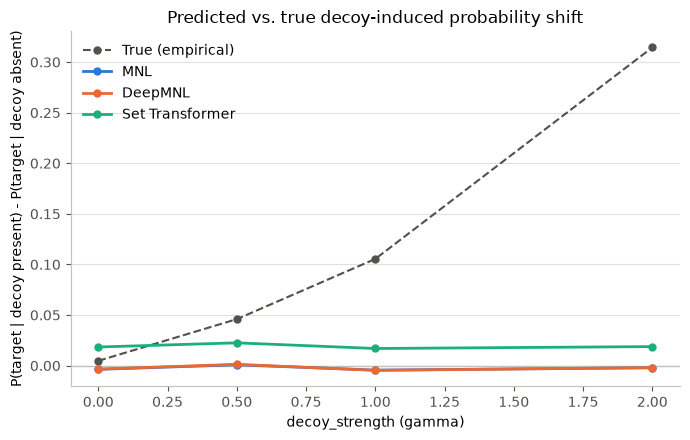

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))

true_row = decoy[decoy["model"] == "True (empirical)"].sort_values("decoy_strength")
ax.plot(true_row["decoy_strength"], true_row["shift"], color=REFERENCE_COLOR, linestyle="--",
        marker="o", markersize=5, linewidth=1.5, label="True (empirical)", zorder=2)

for model, color in COLORS.items():
    sub = decoy[decoy["model"] == model].sort_values("decoy_strength")
    ax.plot(sub["decoy_strength"], sub["shift"], color=color, marker="o", markersize=5,
            linewidth=2, label=model, zorder=3)

ax.axhline(0, color=AXIS_COLOR, linewidth=1, zorder=1)
ax.set_xlabel("decoy_strength (gamma)")
ax.set_ylabel("P(target | decoy present) - P(target | decoy absent)")
ax.set_title("Predicted vs. true decoy-induced probability shift")
style_ax(ax)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


**The honest read of this plot:** the gap between the dashed gray line and
every model's line is large, and it grows with `decoy_strength` -- none of
the three models come close to recovering the true effect magnitude. This
is the finding from `decisions.md` stated visually: the Set Transformer
captures roughly 6-50% of the true effect (worse at higher `decoy_strength`,
where it matters most) and its response barely scales with `decoy_strength`
at all, staying in a narrow band regardless of how strong the true effect
actually is.

Because the true line so dwarfs the model lines on a shared axis, the (real,
tested) *differences between the three models* are hard to see in this
view. The next plot zooms in on just the model lines to make that
comparison legible -- not to hide the gap above, but because a shared axis
that shows the honest scale of the gap necessarily compresses the smaller
signal underneath it.


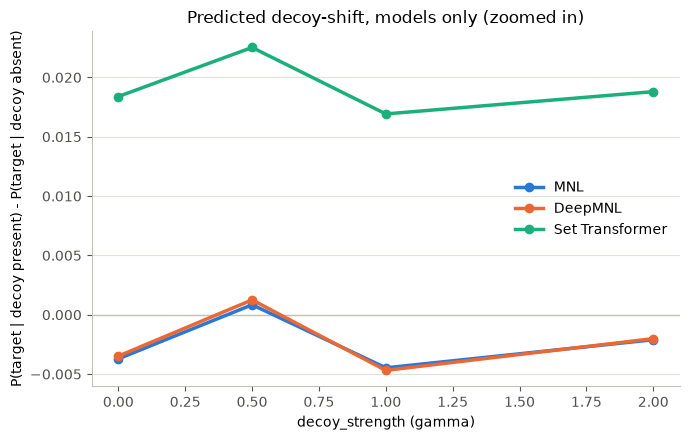

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for model, color in COLORS.items():
    sub = decoy[decoy["model"] == model].sort_values("decoy_strength")
    ax.plot(sub["decoy_strength"], sub["shift"], color=color, marker="o", markersize=6,
            linewidth=2.5, label=model, zorder=3)

ax.axhline(0, color=AXIS_COLOR, linewidth=1, zorder=1)
ax.set_xlabel("decoy_strength (gamma)")
ax.set_ylabel("P(target | decoy present) - P(target | decoy absent)")
ax.set_title("Predicted decoy-shift, models only (zoomed in)")
style_ax(ax)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


**What this zoomed view shows:** MNL and DeepMNL's raw shift is often
*negative* -- expected, not a bug (see `decisions.md`): a `decoy_treated`
set has one more competing alternative than its matched `decoy_control`
set by construction, which mechanically dilutes raw predicted probability
through the softmax denominator regardless of any genuine attraction
effect. A well-fit, correctly-specified model *should* show this. The Set
Transformer sits consistently above both of them at every `decoy_strength`
level -- a real, comparative signal (checked for robustness across 4
independent data seeds in `decisions.md`, holding in all 4) even though
none of the three models recover the true effect's magnitude or its
scaling with `decoy_strength`.


## Summary

- MNL and DeepMNL are both **structurally** unable to see the injected
  context effect (verified architecturally, not just empirically -- see
  `decisions.md`), and their NLL confirms it: near-Bayes-optimal where
  there's no effect to miss, degrading as the effect strengthens.
- The Set Transformer is **never worse** than MNL/DeepMNL on NLL and
  **modestly better** as the effect strengthens. Its predicted
  probabilities move in the correct direction relative to MNL/DeepMNL where
  they structurally cannot move at all -- a real, comparative, statistically
  checked signal.
- But this is a **partial result, not a clean win**: the Transformer
  recovers only a small fraction of the true effect's magnitude, and its
  response barely calibrates to how strong the effect actually is. Accuracy
  (as opposed to NLL) is a genuinely mixed picture, not a consistent win.

This is reported as exactly that -- a real but incomplete validation of the
core hypothesis -- rather than forced into a cleaner story than the data
supports. Full investigation, including the multi-seed robustness checks
and working hypotheses for *why* the recovery is partial, is in
`decisions.md`.
